# Data Analysis & Cleaning

## Overview

This notebook loads, cleans, and enriches the Book-Crossing dataset.

### Data Flow Summary

```
Raw Data
│
├── Books.csv (271,360 rows)
│   ├── Drop image columns
│   ├── Fix Year/Publisher shifts (3 bad rows)
│   ├── Fix mojibake encoding (ftfy)
│   ├── Convert Year to int
│   ├── Drop Year=0 (invalid)
│   ├── Merge with support for Subjects + Language
│   ├── Drop books with TotalRating < 2
│   └── Drop books not in ratings
│
├── Users.csv (278,858 rows)
│   ├── Drop Location
│   ├── Drop Age (40% missing)
│   └── Keep only users with ratings
│
└── Ratings.csv (1,149,780 rows)
    ├── Drop duplicates
    ├── Drop Rating=0 (implicit missing)
    ├── Drop ratings for books not in books
    ├── Drop ratings for users not in users
    └── Compute TotalRating per book
```

In [1]:
import numpy as np
np.set_printoptions(legacy="1.21")
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import os

# Load data & EDA

In [2]:
# to short the code
details_datasets = {"sep":",",
    "encoding":"UTF-8",
    "on_bad_lines":"skip"}
# loading data
books = pd.read_csv("archive/Books.csv", **details_datasets)
users = pd.read_csv("archive/Users.csv", **details_datasets)
ratings = pd.read_csv("archive/Ratings.csv", **details_datasets)

In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
#Images of books are not going to be used here, we can drop them.
books.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1, inplace = True)

In [5]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
#Location is a weak demographic proxy for taste. Direct signal beats proxy signal almost every time, 
#so the marginal information is near zero.
#Location is not going to be used here, we can drop it.
users.drop(['Location'], axis=1, inplace = True)

In [7]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
books = books.rename(columns={
    "Book-Title": "Title",
    "Book-Author": "Author",
    "Year-Of-Publication": "Year"#,
    #"Image-URL-S": "ImgS",
    #"Image-URL-M": "ImgM",
    #"Image-URL-L": "ImgL"
})

users = users.rename(columns={"User-ID": "UserID"})
ratings = ratings.rename(columns={
    "User-ID": "UserID",
    "Book-Rating": "Rating"
})
print(books.shape)
print(users.shape)
print(ratings.shape)

(271360, 5)
(278858, 2)
(1149780, 3)


## books

In [9]:
#checking data types of columns
books.info() ; books.describe()
# Year and ISBN are not numerical categories
# missing two authors, two publisers (or autonomously published) and three ImageUrlL 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271360 non-null  object
 1   Title      271360 non-null  object
 2   Author     271358 non-null  object
 3   Year       271360 non-null  object
 4   Publisher  271358 non-null  object
dtypes: object(5)
memory usage: 10.4+ MB


,ISBN,Title,Author,Year,Publisher
count,271360,271360,271358,271360,271358
unique,271360,242135,102022,202,16807
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin
freq,1,27,632,13903,7535


In [10]:
#FIRST, delete duplicates if any
books.drop_duplicates(inplace=True)
# Check the data type of the Year column
books.Year.apply(type).value_counts()        # shows int vs str counts --> the corruption
#65536 strings!

Year
<class 'int'>    205824
<class 'str'>     65536
Name: count, dtype: int64

In [11]:
bad_year = pd.to_numeric(books['Year'], errors='coerce').isna()
print(bad_year.sum(), "non-numeric Year values")
print(books.loc[bad_year, 'Year'].unique())   

3 non-numeric Year values
['DK Publishing Inc' 'Gallimard']


In [12]:
books.loc[bad_year, 'Year']

209538    DK Publishing Inc
220731            Gallimard
221678    DK Publishing Inc
Name: Year, dtype: object

In [13]:
# Checking entries in books with the wrong year
pd.set_option('display.max_colwidth', 1)
books[books.Year.isin(books.loc[bad_year, 'Year'])]

,ISBN,Title,Author,Year,Publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)\"";Michael Teitelbaum""",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.01.THUMBZZZ.jpg
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-Marie Gustave Le ClÃ?Â©zio""",2003,Gallimard,http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)\"";James Buckley""",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.01.THUMBZZZ.jpg


In [14]:
pd.reset_option('display.max_colwidth')

Every column from `Author` onward is shifted left by one. This is in accordance to the three `NaN` in ImgL above.
The author is attached to `Title` followed by \\"; 

In [15]:
fix = books.loc[bad_year].copy()
# 1) shift the whole tail one column to the right (positional, via .values)
src = books.columns[2:-1]#['Author', 'Year', 'Publisher', 'ImgS', 'ImgM']
dst = books.columns[3:]#['Year', 'Publisher', 'ImgS', 'ImgM', 'ImgL']
fix[dst] = fix[src].values

# 2) split the real title and author out of the Title cell (joined by  ";  )
parts = fix['Title'].str.split('\\";', n=1, regex=False, expand=True)
fix['Title']  = parts[0].str.strip(' "\\')
fix['Author'] = parts[1].str.strip(' "')

# write the repaired rows back
books.loc[bad_year] = fix

In [16]:
with open('archive/Books.csv', 'rb') as f:
    for raw in f:
        if b'Peuple du ciel' in raw:        # the Le Clézio row's title
            print(raw)
            break

b'2070426769,"Peuple du ciel, suivi de \'Les Bergers\\"";Jean-Marie Gustave Le Cl\xc3\x83?\xc3\x82\xc2\xa9zio""",2003,Gallimard,http://images.amazon.com/images/P/2070426769.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/2070426769.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/2070426769.01.LZZZZZZZ.jpg,\n'


Raw file entries... \xc3\x83?\xc3\x82\xc2\xa9 is not recorgnize. Solution -->

In [17]:
#Repairing mojibake on Title, Author and Publisher
import ftfy
def repair(s):
    if not isinstance(s, str):
        return s
    # only touch strings that show mojibake, so legit characters are left alone
    if any(c in s for c in 'ÃÂ\ufffd'):
        s = s.replace('\ufffd', '').replace('?', '')   # drop the noise byte(s)
        return ftfy.fix_text(s).strip()                # then reverse the mojibake
    return s

for col in ['Title', 'Author', 'Publisher']:
    books[col] = books[col].map(repair)

In [18]:
#checking previous erros and typos
books.iloc[[220731, 209538, 221678]]

,ISBN,Title,Author,Year,Publisher
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers",Jean-Marie Gustave Le Clézio,2003,Gallimard
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",Michael Teitelbaum,2000,DK Publishing Inc
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",James Buckley,2000,DK Publishing Inc


In [19]:
broken = books['Author'].str.contains('\ufffd', na=False) # Find strange/foreign characters
books.loc[broken, ['ISBN', 'Author']] 
# All fixed, no more mojibake in Author column

,ISBN,Author


In [20]:
# Books with missing authors
books.loc[books['Author'].isnull()]
# only two books with missing authors, we can check them later if needed.

,ISBN,Title,Author,Year,Publisher
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing


### Year
Data was published in 2004, so year after 2003 (may be) incorrect

In [21]:
#checking years
books.Year=pd.to_numeric(books.Year, errors='coerce')
books.Year = books.Year.astype(np.int32)
print(sorted(books['Year'].unique()))

[0, 1376, 1378, 1806, 1897, 1900, 1901, 1902, 1904, 1906, 1908, 1909, 1910, 1911, 1914, 1917, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2008, 2010, 2011, 2012, 2020, 2021, 2024, 2026, 2030, 2037, 2038, 2050]


Year of publication goes from 0 to 2025. This is not correct. We will fix it in accordance to the year of Publication for a given ISBN using **Openlibrary API**. This will be performed on the data that is going to be used for calculation in order to save time.

In [22]:
books.Year[books.Year == 0].count()

4618

In [23]:
# pertentage of possible wrong years in the dataset
(books.Year[(books.Year == 0) | (books.Year >= 2004)].count() / len(books)) * 100
# Less than a 4% of the dataset, we can drop them if needed

3.8800854952830184

## Users

In [24]:
users.drop_duplicates(inplace=True)
users.info(); users.Age.describe()
# Around 40% of user ages are missing.
#There are ages above 100, which are likely to be errors. We can take only ages from 5 to 95.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   UserID  278858 non-null  int64  
 1   Age     168096 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 4.3 MB


count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64

<Axes: >

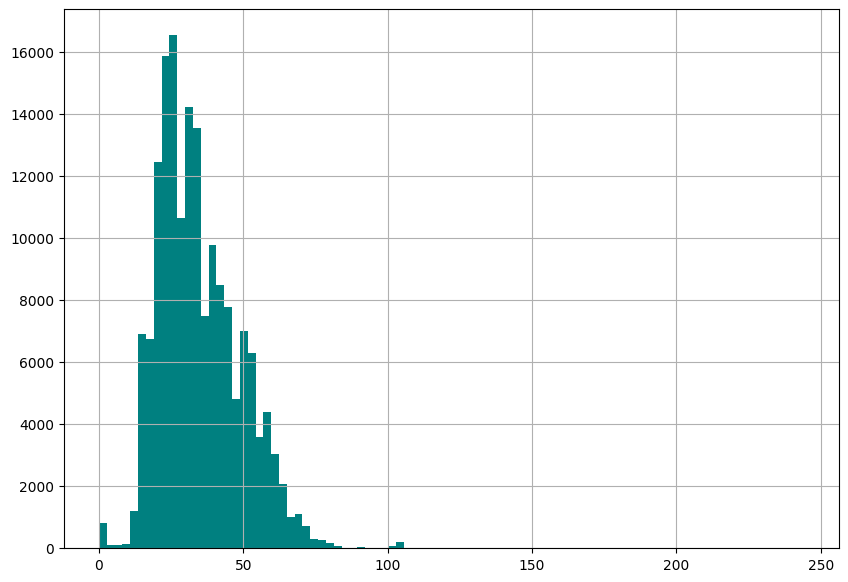

In [25]:
plt.figure(figsize=(10, 7))
users.Age.hist(bins=90, color='teal')

In [26]:
# percentage of users with age below 5 or above 95
users.loc[(users.Age >= 5) & (users.Age <= 95), 'Age'].count() / len(users) * 100
# 60% of users has a reliable/adequate age.

59.82578946990942

In [27]:
# pertenatge of users with missing age 
(users.Age.isna().sum())/len(users) * 100
#Almost 40% of the user ages is unreliable or does not contribute to the analysis, so we can drop this feature. 

39.71985741847105

### Recovering age from rating behaviour (instead of dropping it)

Age is missing or out-of-range (<5 or >95) for ~45% of users, but it is a useful
similarity signal: people of similar age tend to read similar authors. So instead
of dropping it outright, we try to **recover** it from behaviour:

1. Using only users with a *reliable* age (5-95), compute a **median age per author**
   over everyone who rated that author.
2. For a user with a bad/missing age, take the authors they rated and use the
   **median of those authors' age profiles** as the imputed age.

We keep every author that has at least one reliable-age rater, to cover as many
missing ages as possible. A single author's profile can be noisy, but step 2 takes
the median over *all* the authors a user rated, which smooths that out. The
`MIN_RATERS` knob below lets you raise the bar later if validation says quality
suffers. Before trusting it, we validate on the reliable-age users with a
train/test split and compare against a naive \"predict the global median age\" baseline.

In [28]:
GOOD_LOW, GOOD_HIGH = 5, 95
MIN_RATERS = 1          # keep every author with >=1 reliable-age rater (maximise coverage);
                        # raise this only if validation shows the imputation is too noisy.

# user -> author for every rating. Rating==0 (implicit) interactions are kept:
# they still tell us which authors a user engages with. Books with no known
# author are dropped via dropna.
ua = (ratings.merge(books[['ISBN', 'Author']].dropna(subset=['Author']),
                    on='ISBN', how='inner')[['UserID', 'Author']])

def author_age_profile(profile_users):
    """Median age per author from `profile_users` (UserID, Age),
    keeping authors with at least MIN_RATERS raters."""
    d = ua.merge(profile_users[['UserID', 'Age']], on='UserID')
    g = d.groupby('Author')['Age'].agg(['median', 'size'])
    return g.loc[g['size'] >= MIN_RATERS, 'median']

def impute_ages(profile, target_user_ids):
    """For each target user, the median age-profile of the authors they rated.
    Aggregating over many authors smooths out noisy single-rater profiles."""
    d = ua[ua['UserID'].isin(target_user_ids)].copy()
    d['author_age'] = d['Author'].map(profile)
    return d.dropna(subset=['author_age']).groupby('UserID')['author_age'].median()

good_mask = users['Age'].between(GOOD_LOW, GOOD_HIGH)   # NaN -> False
good = users[good_mask]
# --- validate: can authors predict age for users whose age we DO know? ---
rng = np.random.default_rng(42)
is_train = rng.random(len(good)) < 0.8
train, test = good[is_train], good[~is_train]

pred  = impute_ages(author_age_profile(train), test['UserID'])
truth = test.set_index('UserID')['Age']
ev = pd.concat([pred.rename('pred'), truth.rename('true')], axis=1).dropna()

mae      = (ev['pred'] - ev['true']).abs().mean()
baseline = (ev['true'] - good['Age'].median()).abs().mean()
print(f"Covered {len(ev)}/{len(test)} test users ({len(ev)/len(test):.0%})")
print(f"Author-based MAE : {mae:.1f} years")
print(f"Baseline  MAE    : {baseline:.1f} years  (predict global median age)")

Covered 10295/33352 test users (31%)
Author-based MAE : 10.5 years
Baseline  MAE    : 11.1 years  (predict global median age)


By construction this method can't stray far from the baseline, and the data confirms it: authors are a poor predictor of age. (Makes sense — popular authors are read across all age groups.)  
Therefore, **we don't use the imputed ages**.

In [29]:
users.drop(['Age'], axis=1, inplace = True)

### Rating

In [30]:
ratings.drop_duplicates(inplace=True)
ratings.info(); ratings.Rating.describe()
ratings["Rating"] = ratings["Rating"].astype("Int32")
ratings["UserID"] = ratings["UserID"].astype("Int32")
#No missing values, but ratings are from 0 to 10, which is unusual. We can check the distribution of ratings.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   UserID  1149780 non-null  int64 
 1   ISBN    1149780 non-null  object
 2   Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [31]:
# unique rating in ascending order 
sorted(ratings['Rating'].unique())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

<Axes: >

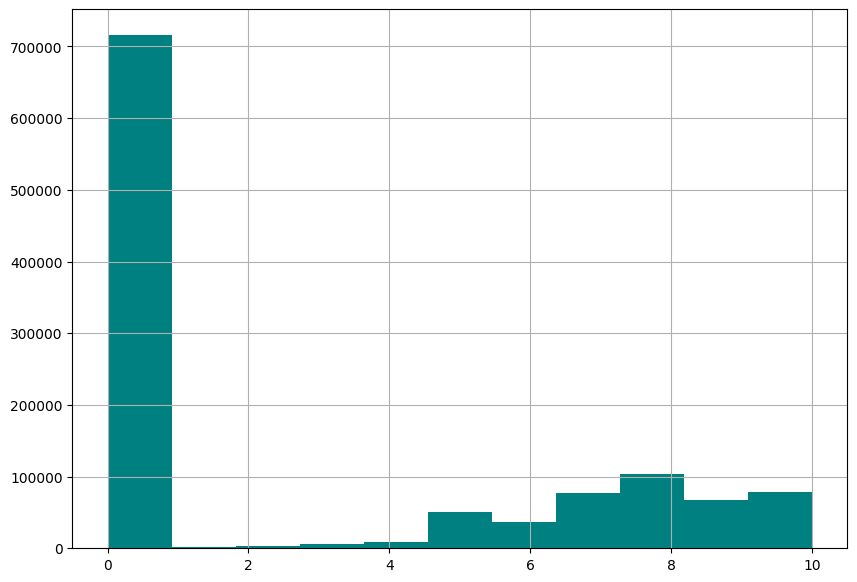

In [32]:
plt.figure(figsize=(10, 7))
ratings.Rating.hist(bins=11, color='teal')

In [33]:
# percentage of 0 ratings
ratings.loc[ratings.Rating == 0, 'Rating'].count()/len(ratings) *100
# Around 62% of ratings are 0, which means many books have not been rated by users, which can be a problem for recommendation systems. 
# We won't pay attention to books with 0 ratings.

62.28226269373272

In [34]:
# We keep ISBN in ratings that contain a rating > 0, because they can be useful for recommendation systems
ratings = ratings[ratings['Rating'] > 0]
print(ratings.shape)

(433671, 3)


In [35]:
# ratings dataset should have books which exist in our books dataset, unless new books are added to books dataset
ratings = ratings[ratings.ISBN.isin(books.ISBN)]
ratings.shape[0]

383842

In [36]:
# ratings dataset should have ratings from users which exist in users dataset, unless new users are added to users datase
ratings = ratings[ratings['UserID'].isin(users['UserID'])]
ratings.shape[0]

383842

Text(0.5, 1.0, 'Distribution of Book Ratings')

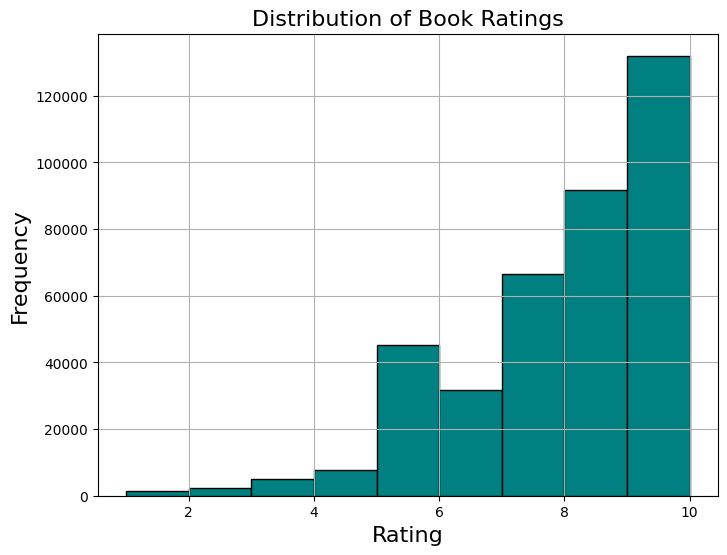

In [37]:
plt.figure(figsize=(8, 6))
ratings.Rating.hist(bins=9, color='teal', edgecolor='black')
# A small percentage of books are rated 1-5.
plt.xlabel('Rating', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title('Distribution of Book Ratings', fontsize=16)

In [38]:
#total percentage of ratings that are 1, 2, 3, 4 or 5
total_low_rating = ratings.loc[ratings.Rating <= 5, 'Rating'].count()/ratings.shape[0] * 100
print(f"Total percentage of ratings 1-5: {total_low_rating:.2f}%")
# around 16% of books have a bad to mediocre rating, which can be useful for recommendation systems to avoid recommending them. We keep the data.

Total percentage of ratings 1-5: 16.14%


# Cleaning the data

In [39]:
# For consistency, we keep the ISBN in books that have been rated, even if they have a low rating, because they can be useful for recommendation systems to avoid recommending them. We keep the data.
books = books[books.ISBN.isin(ratings.ISBN)]
ratings = ratings[ratings.ISBN.isin(books.ISBN)]
(books.shape[0], ratings.shape[0])

(149836, 383842)

In [40]:
# Checking missing authors
# First we consider the number of ratings for books with missing authors, to see if they are relevant for the analysis.
books['TotalRating'] = books['ISBN'].map(ratings.groupby('ISBN')['Rating'].count())
nan_authors = books.loc[books['Author'].isna()]
nan_authors
# They have been rated only once, so they are not relevant for the analysis, we can drop them.

,ISBN,Title,Author,Year,Publisher,TotalRating
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,1
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,1


In [41]:
# drop books with TotalRating < 2
books = books[books.TotalRating >= 2]

In [42]:
misleading_books = books[(books.Year < 1800) | (books.Year > 2003)]
len(misleading_books)/len(books)*100
#misleading_books[lambda df: df.TotalRating >= 2]


4.434484263133887

In [43]:
# load supporting dataset, obtained from ratings, with books rated at least 2 times.
# it contains Year, Subjets, Publisher and Language obtained from OpenLibrary API
support = pd.read_csv("support/enriched_books_checkpoint.csv", dtype={"Year": "Int32"})
support.head(5)

,ISBN,Year,Subjects,Publisher,Language
0,0395193958,1987,"['The Lord of the Rings', 'Fiction']",Houghton Mifflin Company,English
1,089471838X,1990,NaN,Running Pr,English
2,0679821481,1991,"['Stories in rhyme', ""Children's stories, Amer...",Random House,English
3,0842377506,1993,"['Fiction, christian, romance', 'Rome, fiction']",Tyndale House,English
4,0044409494,1995,"['Entertainers, united states', 'Postcards']",HarperSanFrancisco,English


In [44]:
# Clean support dataset (remove duplicates)
print(f"Support before dedup: {len(support)} rows")

# Check for duplicates
duplicate_isbns = support[support.duplicated(subset=['ISBN'], keep=False)]
if len(duplicate_isbns) > 0:
    print(f"Found {len(duplicate_isbns)} duplicate rows ({duplicate_isbns['ISBN'].nunique()} unique ISBNs)")
    print("Example duplicates:")
    display(duplicate_isbns.sort_values('ISBN').head(5))
# No duplicates

Support before dedup: 50399 rows


In [45]:
# Also dedup books if needed
books_before = len(books)
books = books.drop_duplicates(subset=['ISBN'], keep='first')
if len(books) < books_before:
    print(f"Books dedup: {books_before} -> {len(books)} rows")
# No duplicates

In [46]:
suspect = books[(books.Year < 1800) | (books.Year > 2003)]
comparison = suspect[['ISBN', 'Year']].merge(
    support[['ISBN', 'Year']], 
    on='ISBN', 
    suffixes=('_books', '_support')
)
comparison.shape[0]



2234

In [47]:
valid_fix = comparison[comparison.Year_support.notna()]
for _, row in valid_fix.iterrows():
    books.loc[books.ISBN == row.ISBN, 'Year'] = row.Year_support

In [48]:
print(sorted(books['Year'].unique()))
# This means that books with wrong years have less than 5 ratings, and probably will be discarded later.

[0, 1505, 1600, 1784, 1815, 1842, 1851, 1863, 1900, 1901, 1902, 1908, 1920, 1922, 1923, 1925, 1926, 1927, 1929, 1930, 1932, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2011, 2012, 2015, 2016, 2017, 2018, 2020, 2026]


In [49]:
books[books.Year == 0].sort_values(by = 'TotalRating', ascending=False)
# By inspection, the books with Year = 0 are mostly books with less than 4 ratings
# and in different languages, so we can drop them.

,ISBN,Title,Author,Year,Publisher,TotalRating
6954,8807811987,"Baol Una Tranquilla Notte Di Regime (Fiction, ...",Benni,0,Feltrinelli,3
14597,3442089832,Der Kuss Kunst Und Lebeb Der Camille Cla,Anne Delbee,0,Goldmann Verlag,3
165159,2266052357,Laffaire Toutankhamon,Christian Jacq,0,European Book Co,3
15404,2070567842,Folio Junior: L'histoire De Monsieur Sommer,Su>skind-Sempe,0,Gallimard-Jeunesse,3
38319,0762101067,Best of Sisters In Crime,Marilyn Wallace,0,Penguin Putnam~childrens Hc,3
81900,8806116770,Garzanti - Gli Elefanti: Notte Della Cometa,Vassalli,0,Einaudi,3
69362,0965664791,By the Light of My Fathers Smile,Alice Walker,0,Random House~trade,3
115117,3404715233,Merlins Geheimnis,Jonathan Gunson,0,Gustav Lubbe Verlag GmbH,3
109865,0330020722,Supreme Storyteller,Nevil Shute,0,Pan Books Ltd,3
95312,8478885218,La Fiesta De Ralph,Lisa Jewell,0,Emece Editores,3


In [50]:
#books[(books.Year < 1800) | (books.Year > 2003)].to_csv("misleading_books.csv", index=False)
books = books[books.Year > 0]


In [51]:
# Checking Publisher
no_pub = books[books.Publisher.isna()]
no_pub
# No book without Publisher

,ISBN,Title,Author,Year,Publisher,TotalRating


### Language

In [52]:
no_language = support.loc[support['Language'] == 'unknown']
no_language
#960 ISBN

,ISBN,Year,Subjects,Publisher,Language
18619,1891575139,1999,NaN,Star's Edge International,unknown
18735,0345373294,1995,"['Fiction, romance, contemporary']",Ballantine Books,unknown
18780,0399128298,1955,"['New Thought', 'New thought']",Grosset & Dunlap,unknown
18803,0451403789,1993,"['Gems', 'Collectors and collecting']",Onyx,unknown
18887,0440166462,1972,NaN,Dell Pub,unknown
...,...,...,...,...,...
50303,3453159071,1999,NaN,Heyne,unknown
50336,0743520548,2002,NaN,Simon & Schuster Audio,unknown
50341,3442451280,2002,NaN,Goldmann,unknown
50347,1558020063,1988,"['Time travel', 'Fiction']",Lynx Books,unknown


In [53]:
# How many ratings do they have?
no_language_books = (
    books[books["ISBN"].isin(set(no_language.ISBN))]
    .sort_values("TotalRating", ascending=False)
    .copy()
)
no_language_books['Language'] = 'unknown'
no_language_books
# books with only 3 or less ratings
# only 928 books are contained in on_language

,ISBN,Title,Author,Year,Publisher,TotalRating,Language
76850,3404142357,At E.R.O.S.,Greg Iles,1999,Lübbe,3,unknown
76782,0553574280,Keeper,Greg Rucka,1997,Bantam Books,3,unknown
76546,0553542842,The Guinness Book of World Records 1997,Norris McWhirter,1997,Bantam Books,3,unknown
75472,0441305989,Gulag,Sean Flannery,1987,Jove Books,3,unknown
75291,0805054952,Easy Meat,John Harvey,1997,Owl Publishing Company,3,unknown
...,...,...,...,...,...,...,...
82959,3596154626,Isabel.,Alain DeBotton,2002,"Fischer (Tb.), Frankfurt",2,unknown
83091,0812520297,Split Heirs,Lawrence Watt-Evans,1994,Tor Books,2,unknown
19314,0751501220,The Limits of Detection,Douglas Wynn,1992,Time Warner Books UK,2,unknown
83650,0575073195,The Wyrdest Link: A Terry Pratchett Discworld ...,Terry Pratchett,2002,Gollancz,2,unknown


In [54]:
support.Language.value_counts(normalize=True)
# Top three languages are English (89%), German (4%) and Spanish (2%)

Language
English       0.889462
German        0.036052
Spanish       0.019286
unknown       0.019048
French        0.018572
Italian       0.003770
und           0.001984
Portuguese    0.001687
Chinese       0.001230
Dutch         0.000893
Russian       0.000893
Polish        0.000853
Catalan       0.000774
Japanese      0.000754
Hebrew        0.000754
Korean        0.000437
Finnish       0.000357
Greek         0.000337
Turkish       0.000317
Vietnamese    0.000298
Ukrainian     0.000258
Bulgarian     0.000238
Czech         0.000198
Hindi         0.000179
cor           0.000159
Swedish       0.000119
mal           0.000099
enm           0.000099
Danish        0.000079
Latin         0.000079
Norwegian     0.000060
bre           0.000060
mul           0.000060
est           0.000040
Croatian      0.000040
Esperanto     0.000040
Arabic        0.000040
Welsh         0.000040
alb           0.000040
san           0.000040
kur           0.000020
gsw           0.000020
kan           0.000020
In

In [55]:
# ---- Lingua fallback: fill ONLY the 'unknown' languages, detecting from the title ----
from lingua import Language, LanguageDetectorBuilder

# the three languages that dominate this catalogue
languages = [Language.ENGLISH] #, Language.GERMAN, Language.SPANISH, Language.FRENCH
detector = (LanguageDetectorBuilder
            .from_languages(*languages)
            .with_preloaded_language_models()
            .build())
# Titles:
title_by_isbn = no_language_books[['Title', 'Author','Publisher']].copy()
is_single_word = title_by_isbn['Title'].str.split().str.len() <= 2
title_by_isbn.loc['Title'] = title_by_isbn['Title']+ ', ' + title_by_isbn['Author'] + ', ' + title_by_isbn['Publisher']
title_by_isbn.drop(['Publisher'], axis=1, inplace=True)

In [56]:
# Raise this to leave weak guesses as 'unknown' (e.g. 0.90, as we explored earlier);
# 0.0 means "always take Lingua's best guess among the six languages".

MIN_CONFIDENCE = 0.0

def classify_title_with_confidence(title):
    if not isinstance(title, str) or not title.strip():
        return "unknown", 0.0
    
    cv_list = detector.compute_language_confidence_values(title)
    
    # Pozor: Lingua vrací seznam objektů. První objekt [0] je nejlepší shoda.
    if not cv_list or cv_list[0].value < MIN_CONFIDENCE:
        return "unknown", 0.0
    
    return cv_list[0].language.name.capitalize(), cv_list[0].value

# 4. Detekce na unikátních upravených titulech (pro rychlost)
unique_titles = title_by_isbn['Title'].fillna("").unique()
lang_mapping = {t: classify_title_with_confidence(t) for t in unique_titles}

# 5. Namapování výsledků na upravené tituly
# Výsledkem je série dvojic, která má stále STEJNÝ INDEX jako no_language_books
mapped_results = title_by_isbn['Title'].fillna("").map(lang_mapping)

# 6. PŘÍMÝ ZÁPIS: Protože indexy sedí, zapíšeme hodnoty rovnou bez hledání podle ISBN sloupce
no_language_books['Language'] = mapped_results.apply(lambda x: x[0] if isinstance(x, tuple) else "unknown")
no_language_books['Confidence'] = mapped_results.apply(lambda x: x[1] if isinstance(x, tuple) else 0.0)

# 7. Kontrola výsledků
no_language_books.sort_values("Confidence", ascending=True).head(10)

,ISBN,Title,Author,Year,Publisher,TotalRating,Language,Confidence
83610,8804448601,Ritorno a Casa,Rosamunde Pilcher,1995,Oscar Italian,3,English,0.0
82157,0345305140,Lusitania,David Butler,1983,Ballantine Books,2,English,0.0
82288,3442452996,E.T.- Der AuÃÂerirdische. Roman zum Film.,William Kotzwinkle,2002,Goldmann,2,English,0.0
82701,0590403745,101 Hamburger Jokes,P. Hirsch,1987,Scholastic Paperbacks (Mm),2,English,0.0
82938,3404258339,Die Frau aus Korsika.,Madge Swidells,2002,Lübbe,2,English,0.0
82959,3596154626,Isabel.,Alain DeBotton,2002,"Fischer (Tb.), Frankfurt",2,English,0.0
83091,0812520297,Split Heirs,Lawrence Watt-Evans,1994,Tor Books,2,English,0.0
82074,0375404783,Bridget Jones's Diary : A Novel,Helen Fielding,1998,Random House Audio,2,English,0.0
248851,0744507839,Moppy Is Happy 011090,J. Asher,1987,Walker Books,2,English,0.0
109837,3404147545,"Drei Männer, vier Pubs und eine Urne.",James Birrell,2002,Lübbe,2,English,0.0


In [57]:
no_language_books[no_language_books["Confidence"] >=0.6].sort_values("Confidence", ascending=True)

,ISBN,Title,Author,Year,Publisher,TotalRating,Language,Confidence
76546,0553542842,The Guinness Book of World Records 1997,Norris McWhirter,1997,Bantam Books,3,English,1.0
74911,0812525051,"Next, After Lucifer",Daniel Rhodes,1988,Tor Books (Mm),3,English,1.0
74095,0192823523,The Interpretation of Dreams (Oxford World's C...,Sigmund Freud,2000,Oxford University Press,3,English,1.0
73534,0821757903,A Priceless Acquisition (Zebra Regency Romance),Cathleen Clare,1997,Zebra Books,3,English,1.0
34279,0684861593,Amy and Isabelle,Elizabeth Strout,1999,Simon Schuster Trade,3,English,1.0
...,...,...,...,...,...,...,...,...
82153,9500417960,Arenas del tiempo,Sidney Sheldon,2000,Emece/Argentina,2,English,1.0
82155,8401321069,El Cuarto Protocolo,Frederick Forsyth,1984,Lectorum Pubns (Adult),2,English,1.0
82640,0861121961,Thank You God (First Prayer Ser),Stephanie Longfoot,1984,Brimax Books Ltd,2,English,1.0
19314,0751501220,The Limits of Detection,Douglas Wynn,1992,Time Warner Books UK,2,English,1.0


<Axes: >

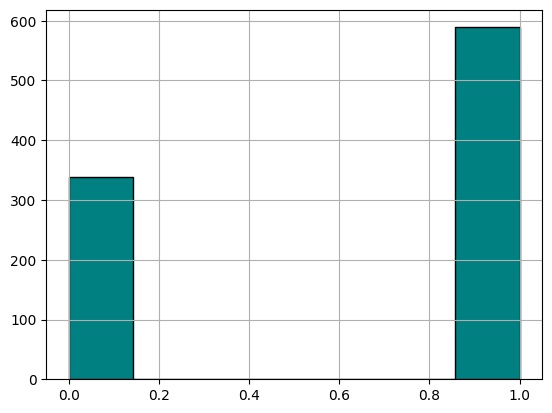

In [58]:
no_language_books.Confidence.hist(bins=7, color='teal', edgecolor='black')

Some books have the wrong predicted language (specially in Spanish and German [not shown]). Therefore we discard Lingua.

In [59]:
# Add the subjects and language from support into books
books = books.merge(support[['ISBN', 'Subjects', 'Language']], on='ISBN', how='left')
books['Language'] = books['Language'].fillna('unknown')   # books not in support -> unknown
books = books[['ISBN', 'Title', 'Author', 'Year', 'Publisher', 'TotalRating', 'Subjects', 'Language']]
books.head()


,ISBN,Title,Author,Year,Publisher,TotalRating,Subjects,Language
0,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,9,"['Actresses', 'Fiction']",English
1,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,2,"['Campaigns', 'History']",English
2,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,6,"['Influenza', 'History']",English
3,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,17,"['Chinese fiction', 'Family']",English
4,1558746218,A Second Chicken Soup for the Woman's Soul (Ch...,Jack Canfield,1998,Health Communications,3,"['Women', 'Conduct of life']",English


In [60]:
# Checking duplicates in OSBN
books[books.ISBN.duplicated(keep=False)].sort_values('ISBN')
#books = books.drop(index=39818)       
# No duplicates

,ISBN,Title,Author,Year,Publisher,TotalRating,Subjects,Language


In [61]:
ratings = ratings[ratings.ISBN.isin(books.ISBN)]
print(books.shape[0], ratings.shape[0], users.shape[0])

50389 284351 278858


In [62]:
# ============================================================
# Final Sanity Checks
# ============================================================

print("=== Final Data Quality Checks ===")

# Check that all ratings have corresponding books
missing_books = ratings[~ratings['ISBN'].isin(books['ISBN'])]
print(f"Ratings with missing books: {len(missing_books)}")

# Check that all ratings have corresponding users
missing_users = ratings[~ratings['UserID'].isin(users['UserID'])]
print(f"Ratings with missing users: {len(missing_users)}")

# Check for negative or zero ratings
bad_ratings = ratings[ratings['Rating'] <= 0]
print(f"Ratings with Rating <= 0: {len(bad_ratings)}")

# Check rating distribution
print(f"Rating stats: min={ratings['Rating'].min()}, max={ratings['Rating'].max()}, mean={ratings['Rating'].mean():.2f}")

# Check book rating distribution
print(f"Books with ratings: {len(books)}")
print(f"Books with >10 ratings: {(books['TotalRating'] > 10).sum()}")

=== Final Data Quality Checks ===
Ratings with missing books: 0
Ratings with missing users: 0
Ratings with Rating <= 0: 0
Rating stats: min=1, max=10, mean=7.67
Books with ratings: 50389
Books with >10 ratings: 4788


In [63]:
# save datasets to output_path. 
output_path = "cleaned_data/"
os.makedirs(output_path, exist_ok=True)
books.to_csv(output_path + "Books.csv", index=False)
users.to_csv(output_path + "Users.csv", index=False)
ratings.to_csv(output_path + "Ratings.csv", index=False)